In [1]:
#Setting up Entrez in Biopython
from Bio import Entrez, SeqIO
Entrez.email = "kannan.ana@northeastern.edu"
print("Entrez set up successfully!")
print("Accessing NCBI as:", Entrez.email)


Entrez set up successfully!
Accessing NCBI as: kannan.ana@northeastern.edu


In [5]:
#Fetching a real gene sequence from NCBI
from Bio import Entrez, SeqIO
Entrez.email = "kannan.ana@northeastern.edu"
handle = Entrez.efetch(db="nucleotide", id="NM_000207", rettype="fasta", retmode="text")
record = SeqIO.read(handle, "fasta")
handle.close()
print("ID:", record.id)
print("Description:", record.description)
print("Sequence length:", len(record.seq))
print("First 100 bases:", record.seq[:100])

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1081)>

In [4]:
import urllib.request
urllib.request.urlopen("https://eutils.ncbi.nlm.nih.gov")
print("Connected!")

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1081)>

In [6]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from Bio import Entrez, SeqIO

Entrez.email = "kannan.ana@northeastern.edu"

handle = Entrez.efetch(db="nucleotide", id="NM_000207", 
                       rettype="fasta", retmode="text")
record = SeqIO.read(handle, "fasta")
handle.close()

print("ID:", record.id)
print("Description:", record.description)
print("Sequence length:", len(record.seq))
print("First 100 bases:", record.seq[:100])

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1081)>

In [7]:
from Bio import SeqIO
record = SeqIO.read("insulin.fasta", "fasta")
print("ID:", record.id)
print("Description:", record.description)
print("Sequence length:", len(record.seq))
print("First 100 bases:", record.seq[:100])

ID: NM_000207.3
Description: NM_000207.3 Homo sapiens insulin (INS), transcript variant 1, mRNA
Sequence length: 465
First 100 bases: AGCCCTCCAGGACAGGCTGCATCAGAAGAGGCCATCAAGCAGATCACTGTCCTTCTGCCATGGCCCTGTGGATGCGCCTCCTGCCCCTGCTGGCGCTGCT


In [8]:
#Analyzing and visualizing the real data
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
files = {
    "Insulin": "insulin.fasta",
    "BRCA1": "brca1.fasta",
    "TP53" : "tp53.fasta",
    "EGFR" : "egfr.fasta", 
    "HBB" : "hbb.fasta"
}
gene_data = []
for gene_name, filename in files.items():
    record = SeqIO.read(filename, "fasta")
    length = len(record.seq)
    gc = round(gc_fraction(record.seq)*100,2)
    gene_data.append({"Gene":gene_name, "Length":length, "GC_Content":gc})
df = pd.DataFrame(gene_data)
print(df)

      Gene  Length  GC_Content
0  Insulin     465       63.87
1    BRCA1    7088       41.77
2     TP53    2512       53.38
3     EGFR    9905       47.78
4      HBB     628       51.27


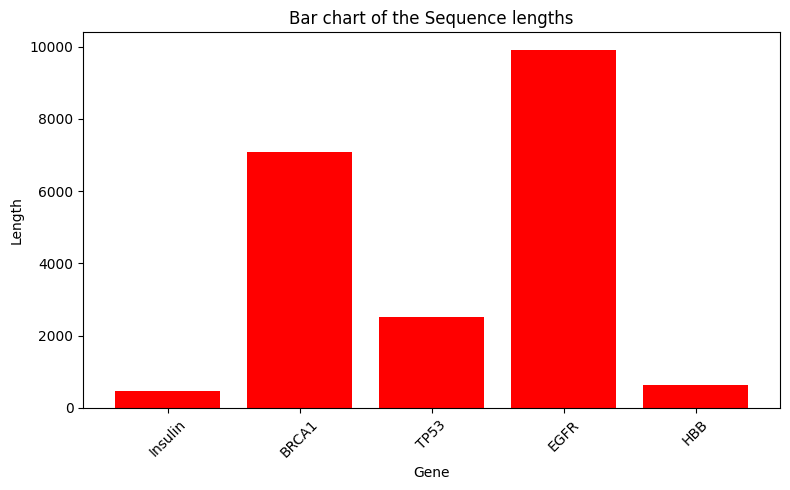

In [9]:
#Exercise 1:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(df["Gene"], df["Length"], color="red")
plt.title("Bar chart of the Sequence lengths")
plt.xlabel("Gene")
plt.ylabel("Length")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

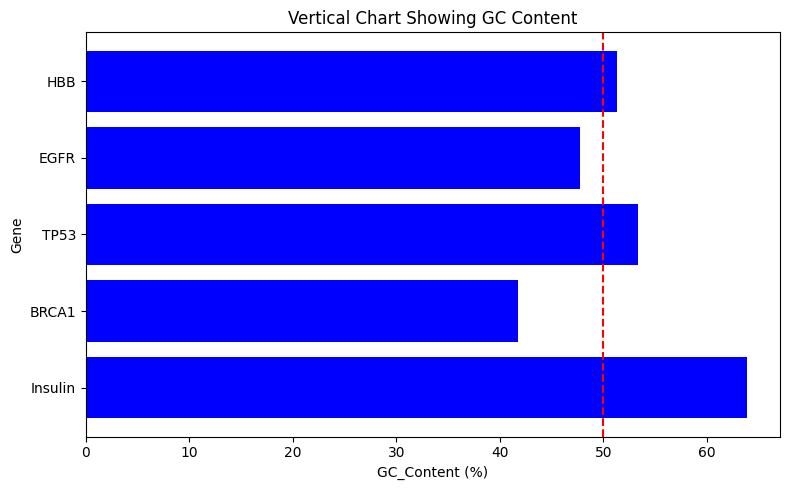

In [11]:
#Exercise 2
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(df["Gene"], df["GC_Content"], color="blue")
plt.axvline(x=50, color="red", linestyle="--")
plt.title("Vertical Chart Showing GC Content")
plt.xlabel("GC_Content (%)")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


In [1]:
#Writing a FASTA File with SeqIO.write()
from Bio import SeqIO
records = []
for filename in ["insulin.fasta", "brca1.fasta", "tp53.fasta", "egfr.fasta", "hbb.fasta"]:
    record = SeqIO.read(filename, "fasta")
    records.append(record)
SeqIO.write(records, "all_genes.fasta", "fasta")
print("Written", len(records), "sequence to all_genes.fasta")
for record in SeqIO.parse("all_genes.fasta", "fasta"):
    print(record.id, len(record.seq))

Written 5 sequence to all_genes.fasta
NM_000207.3 465
NM_007294.4 7088
NM_000546.6 2512
NM_005228.5 9905
NM_000518.5 628


In [2]:
#Filtering and writing specific sequences
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
filtered_records = []
for record in SeqIO.parse("all_genes.fasta", "fasta"):
    gc = gc_fraction(record.seq) * 100
    if len(record.seq) > 600:
        filtered_records.append(record)
SeqIO.write(filtered_records, "long_genes.fasta", "fasta")
print("Filtered sequences saved:", len(filtered_records))
for record in SeqIO.parse("long_genes.fasta", "fasta"):
    print(record.id, len(record.seq))


Filtered sequences saved: 4
NM_007294.4 7088
NM_000546.6 2512
NM_005228.5 9905
NM_000518.5 628


In [3]:
#Creating a SeqRecord from stratch and writing it
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
my_sequences = []
seq1 = SeqRecord(Seq("ATGCGTACGTAGCTAGCTAGCTAGCATGCGT"), id = "Custom_Gene_1", description = "Custom designed primer sequence")
seq2 = SeqRecord(Seq("ATGGAGGAGCCGCAGTCAGATCCTAGCAGAG"), id = "Custom_Gene_2", description = "Synthetic cancer gene sequence")
seq3 = SeqRecord(Seq("ATGCCCCTGTGGATGCGCCTCCTGCCCCTGCT"), id = "Custom_Gene_3", description = "Custom insulin promoter sequence")
my_sequences.append(seq1)
my_sequences.append(seq2)
my_sequences.append(seq3)
SeqIO.write(my_sequences, "custom_sequences.fasta", "fasta")
print("Custom FASTA file created!")
for record in SeqIO.parse("custom_sequences.fasta", "fasta"):
    print(record.id, "-", record.description)
    print(record.seq)
    print("---")

Custom FASTA file created!
Custom_Gene_1 - Custom_Gene_1 Custom designed primer sequence
ATGCGTACGTAGCTAGCTAGCTAGCATGCGT
---
Custom_Gene_2 - Custom_Gene_2 Synthetic cancer gene sequence
ATGGAGGAGCCGCAGTCAGATCCTAGCAGAG
---
Custom_Gene_3 - Custom_Gene_3 Custom insulin promoter sequence
ATGCCCCTGTGGATGCGCCTCCTGCCCCTGCT
---


In [7]:
#Exercise 1
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
filtered_record = []
for record in SeqIO.parse("all_genes.fasta", "fasta"):
    gc = round(gc_fraction(record.seq) * 100, 2)
    if gc > 50:
        filtered_record.append(record)
SeqIO.write(filtered_record, "high_gc_genes.fasta", "fasta")
print("Filtered sequences saved:", len(filtered_record))
for record in SeqIO.parse("high_gc_genes.fasta", "fasta"):
    gc = round(gc_fraction(record.seq) * 100, 2)
    print(record.id, gc)
    
        

Filtered sequences saved: 3
NM_000207.3 63.87
NM_000546.6 53.38
NM_000518.5 51.27


In [8]:
#Exercise 2:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
my_proteins = []
Protein_1 = SeqRecord(Seq("AGVLGVLAVLGAVLAGV"), id = "Custom_Protein_1", description = "Custom membrane binding protein")
Protein_2 = SeqRecord(Seq("PIFWIFWPFWPIWPIF"), id = "Custom_Protein_2", description = "Synthetic tumor supression protein")
Protein_3 = SeqRecord(Seq("WMSTMSTWSTWMTMSW"), id = "Custom_Protein_3", description = "Insulin Receptor protein")
my_proteins.append(Protein_1)
my_proteins.append(Protein_2)
my_proteins.append(Protein_3)
SeqIO.write(my_proteins, "my_proteins.fasta", "fasta")
print("Protein sequence FASTA file created!")
for record in SeqIO.parse("my_proteins.fasta", "fasta"):
    print(record.id, "-", record.description)
    print(record.seq)
    print("---")

Protein sequence FASTA file created!
Custom_Protein_1 - Custom_Protein_1 Custom membrane binding protein
AGVLGVLAVLGAVLAGV
---
Custom_Protein_2 - Custom_Protein_2 Synthetic tumor supression protein
PIFWIFWPFWPIWPIF
---
Custom_Protein_3 - Custom_Protein_3 Insulin Receptor protein
WMSTMSTWSTWMTMSW
---
